## In this notebook i will explore the EllipticBitcoinDataset and understand how its constructed and the nature of the graph. This will lay the groundwork for the loader and the models i will train.

> Historical note: this notebook records the original exploration with all 165 PyG features and older PR-AUC wording. The production pipeline uses 93 transaction-local features and reports Average Precision so streaming inference does not depend on forward neighbor aggregates.

In [1]:
%pip install \
  torch-geometric==2.8.0 \
  pandas \
  "numpy<2" \
  matplotlib \
  xgboost \
  scikit-learn \
  jupyter \
  ipykernel \
  nbconvert

In [2]:
import sys
print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [3]:
%pip install --no-index \
  "pyg-lib==0.4.0+pt26cu124" \
  -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [4]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch_geometric
from torch_geometric.datasets import EllipticBitcoinDataset

print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)

PyTorch: 2.6.0+cu124
PyG: 2.8.0


In [5]:
dataset = EllipticBitcoinDataset(root="../data/elliptic")

print(dataset)
print("Number of graphs:", len(dataset))

Processing...


EllipticBitcoinDataset()
Number of graphs: 1


Done!


In [6]:
data=dataset[0]
print(data)
print("\n")
print(data.keys())

Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])


['x', 'edge_index', 'y', 'test_mask', 'train_mask']


In [7]:
print("x:", data.x.shape)
print("\n")
print("edge_index:", data.edge_index.shape)
print("\n")
print("y:", data.y.shape)
print("\n")
print("train_mask:", data.train_mask.shape)
print("\n")
print("test_mask:", data.test_mask.shape)

x: torch.Size([203769, 165])


edge_index: torch.Size([2, 234355])


y: torch.Size([203769])


train_mask: torch.Size([203769])


test_mask: torch.Size([203769])


In [8]:
node_id = 0

print("Features:")
print(data.x[node_id])

print("\nLabel:")
print(data.y[node_id])

Features:
tensor([-1.7147e-01, -1.8467e-01, -1.2014e+00, -1.2197e-01, -4.3875e-02,
        -1.1300e-01, -6.1584e-02, -1.6210e-01, -1.6793e-01, -4.9707e-02,
        -1.6440e-01, -2.8741e-02, -3.5391e-02, -4.2955e-02, -1.3282e-02,
        -5.7195e-02, -1.6961e-01, -1.7115e-01, -1.7447e-01, -1.3737e+00,
        -1.3715e+00, -1.3973e-01, -1.4891e-01, -8.0147e-02, -1.5566e-01,
        -1.0763e-02, -1.2107e-02, -1.3973e-01, -1.4891e-01, -8.0147e-02,
        -1.5566e-01, -1.0669e-02, -1.2005e-02, -2.4669e-02, -3.1272e-02,
        -2.3045e-02, -2.6215e-02,  1.4278e-03,  1.4826e-03, -2.2722e-01,
        -2.3937e-01, -7.5256e-02, -2.3495e-01,  3.7468e-02,  4.3444e-02,
        -2.2720e-01, -2.4324e-01, -9.7895e-02, -2.3590e-01,  3.6577e-02,
         4.2345e-02, -4.1401e-01, -4.8834e-01, -2.3255e-01, -4.6755e-01,
         4.8767e-02,  5.2956e-02, -3.9149e-02, -1.7290e-01, -1.6313e-01,
        -1.6093e-01, -1.3163e+00, -1.3154e+00, -3.9144e-02, -1.7288e-01,
        -1.6311e-01, -1.6093e-01, -1.3163

## Here i will have a look at the class distribution

0 42019
1 4545
2 157205


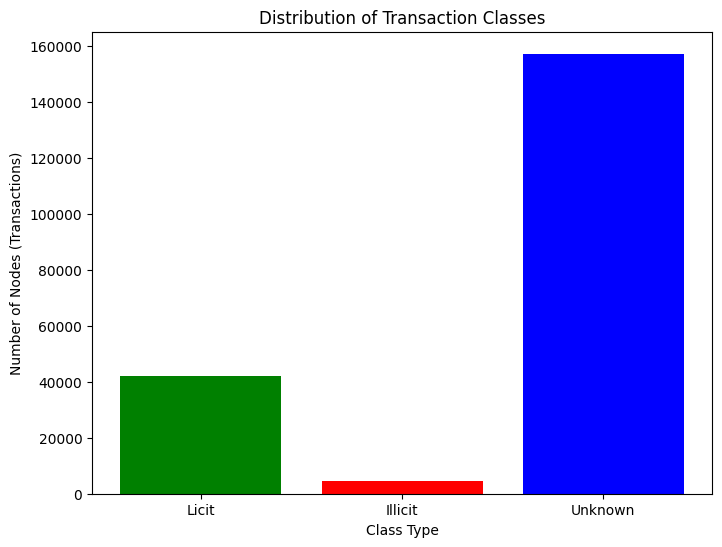

In [9]:
labels, counts = torch.unique(data.y, return_counts=True)

for label, count in zip(labels.tolist(), counts.tolist()):
    print(label, count)

class_names = {0: 'Licit', 1: 'Illicit', 2: 'Unknown'}
plot_labels = [class_names[label] for label in labels.tolist()]

plt.figure(figsize=(8, 6))
plt.bar(plot_labels, counts.tolist(), color=['green', 'red', 'blue'])
plt.xlabel('Class Type')
plt.ylabel('Number of Nodes (Transactions)')
plt.title('Distribution of Transaction Classes')
plt.show()

## I am going to implement a split according to :

###Train       1–30

###Validation 31–34

##Test       35–49

## PyG provides its own split according to:
### Train       1–34 Test       35–49


## So I will have to explicitly recover timestep from the raw file.

In [10]:
dataset.raw_paths

['../data/elliptic/raw/elliptic_txs_features.csv',
 '../data/elliptic/raw/elliptic_txs_edgelist.csv',
 '../data/elliptic/raw/elliptic_txs_classes.csv']

In [11]:
features_raw = pd.read_csv(dataset.raw_paths[0],header=None
)

features_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [12]:
features_raw = features_raw.rename(columns={0: "txId", 1: "time_step"
    }
)

features_raw[["txId", "time_step"]].head(1000)

,txId,time_step
0,230425980,1
1,5530458,1
2,232022460,1
3,232438397,1
4,230460314,1
...,...,...
995,23316173,1
996,232417457,1
997,58836743,1
998,36566888,1


In [13]:
features_raw["time_step"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

## I create a tensor based on the timesteps 1-49

In [14]:
time_step=torch.tensor(features_raw["time_step"].to_numpy(),
    dtype=torch.long)

print(time_step.shape)
print(time_step.min(), time_step.max())

torch.Size([203769])
tensor(1) tensor(49)


## I exclude the classes = 2 where the label is unknown. I create my own split.

In [15]:
known = data.y != 2

train_mask = (
    (time_step >= 1) &
    (time_step <= 30) &
    known
)

val_mask = (
    (time_step >= 31) &
    (time_step <= 34) &
    known
)

test_mask = (
    (time_step >= 35) &
    (time_step <= 49) &
    known
)

In [16]:
from torch_geometric.utils import degree

src = data.edge_index[0]
dst = data.edge_index[1]

out_degree = degree(src, num_nodes=data.num_nodes)
in_degree = degree(dst, num_nodes=data.num_nodes)

print("Average in-degree:", in_degree.mean().item())
print("Average out-degree:", out_degree.mean().item())

print("Max in-degree:", in_degree.max().item())
print("Max out-degree:", out_degree.max().item())



Average in-degree: 1.1501013040542603
Average out-degree: 1.1501013040542603
Max in-degree: 284.0
Max out-degree: 472.0


## Here i look at edge degree for illicit and licit transactions

In [17]:
for label, name in [(0, "licit"), (1, "illicit")]:
    mask = data.y == label

    print(name,"mean in-degree:",in_degree[mask].mean().item(),"mean out-degree:",out_degree[mask].mean().item()
    )

licit mean in-degree: 1.909398078918457 mean out-degree: 1.1858206987380981
illicit mean in-degree: 1.269966959953308 mean out-degree: 0.7416941523551941


In [18]:
for label, name in [(0, "licit"), (1, "illicit")]:
    mask = data.y == label

    print(f"\n{name.upper()}")

    for q in [0.25, 0.5, 0.75, 0.9, 0.99]:
        print(
            f"{q:>4}:",
            "in =", torch.quantile(in_degree[mask], q).item(),
            "out =", torch.quantile(out_degree[mask], q).item()
        )


LICIT
0.25: in = 0.0 out = 1.0
 0.5: in = 1.0 out = 1.0
0.75: in = 1.0 out = 1.0
 0.9: in = 3.0 out = 2.0
0.99: in = 26.0 out = 7.0

ILLICIT
0.25: in = 0.0 out = 0.0
 0.5: in = 1.0 out = 1.0
0.75: in = 1.0 out = 1.0
 0.9: in = 1.0 out = 1.0
0.99: in = 4.0 out = 2.0


In [19]:
X_train = data.x[train_mask].numpy()
y_train = data.y[train_mask].numpy()

X_val = data.x[val_mask].numpy()
y_val = data.y[val_mask].numpy()

X_test = data.x[test_mask].numpy()
y_test = data.y[test_mask].numpy()

In [20]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(26905, 165) (26905,)
(2989, 165) (2989,)
(16670, 165) (16670,)


### Here I implement the XGboost baseline model

In [21]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import (average_precision_score,precision_recall_curve,classification_report,confusion_matrix,precision_score, recall_score,precision_score, recall_score,
)

print("XGBoost version:", xgb.__version__)

XGBoost version: 2.1.4


### Now i prepare the training, test and validation data

In [22]:
X_train = data.x[train_mask].numpy()
y_train = data.y[train_mask].numpy()

X_val = data.x[val_mask].numpy()
y_val = data.y[val_mask].numpy()

X_test = data.x[test_mask].numpy()
y_test = data.y[test_mask].numpy()

In [23]:
print("Train:")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nValidation:")
print("X:", X_val.shape)
print("y:", y_val.shape)

print("\nTest:")
print("X:", X_test.shape)
print("y:", y_test.shape)

Train:
X: (26905, 165)
y: (26905,)

Validation:
X: (2989, 165)
y: (2989,)

Test:
X: (16670, 165)
y: (16670,)


In [24]:
XGBmodel = XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=42,
)
XGBmodel

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [25]:
XGBmodel.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [26]:
print(XGBmodel.get_booster().num_boosted_rounds())

100


In [27]:
y_val_prob = XGBmodel.predict_proba(X_val)[:, 1]

In [28]:
y_val_prob[:20]

array([9.00960003e-05, 2.55674677e-04, 9.15103999e-04, 4.19257303e-05,
       1.42941444e-05, 1.20934135e-04, 5.90634707e-04, 9.99076009e-01,
       2.22749339e-04, 7.98817840e-04, 5.60086446e-05, 1.53814399e-05,
       1.07879305e-05, 1.81522319e-06, 1.61176013e-05, 2.64334594e-05,
       9.99585330e-01, 9.99872684e-01, 9.33023155e-01, 8.70520771e-01],
      dtype=float32)

In [29]:
val_pr_auc = average_precision_score(y_val,y_val_prob,
)

print("Validation PR-AUC:", val_pr_auc)

Validation PR-AUC: 0.9914368055630917


### Treshold grid search best balance found at treshold  at $0.2$.

In [30]:
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.85]:
    y_pred = (y_val_prob >= threshold).astype(int)

    from sklearn.metrics import precision_score, recall_score

    p = precision_score(y_val, y_pred)
    r = recall_score(y_val, y_pred)

    print(
        f"Threshold={threshold:.2f} "
        f"Precision={p:.3f} "
        f"Recall={r:.3f}"
    )

Threshold=0.10 Precision=0.899 Recall=0.982
Threshold=0.20 Precision=0.945 Recall=0.978
Threshold=0.30 Precision=0.963 Recall=0.972
Threshold=0.40 Precision=0.972 Recall=0.967
Threshold=0.50 Precision=0.974 Recall=0.961
Threshold=0.70 Precision=0.987 Recall=0.923
Threshold=0.85 Precision=0.991 Recall=0.823


In [31]:
from sklearn.metrics import average_precision_score

val_pr_auc = average_precision_score(
    y_val,
    y_val_prob
)

print(f"Validation PR-AUC: {val_pr_auc:.4f}")

Validation PR-AUC: 0.9914


In [32]:
from sklearn.metrics import f1_score

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.85]:
    y_pred = (y_val_prob >= threshold).astype(int)

    f1 = f1_score(y_val, y_pred)

    print(
        f"Threshold={threshold:.2f} "
        f"F1={f1:.3f}"
    )

Threshold=0.10 F1=0.939
Threshold=0.20 F1=0.961
Threshold=0.30 F1=0.968
Threshold=0.40 F1=0.969
Threshold=0.50 F1=0.967
Threshold=0.70 F1=0.954
Threshold=0.85 F1=0.899


In [33]:
from sklearn.metrics import (average_precision_score,precision_score,recall_score,f1_score,
                             confusion_matrix,
                             classification_report,
)

y_test_prob = XGBmodel.predict_proba(X_test)[:, 1]

threshold = 0.2

y_test_pred = (y_test_prob >= threshold).astype(int)

## Lets test the model on the test data. This will be our baseline.

In [34]:
test_pr_auc = average_precision_score(y_test, y_test_prob,
)

print(f"Test PR-AUC: {test_pr_auc:.4f}")

test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Threshold: {threshold:.2f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1:        {test_f1:.4f}")

cm = confusion_matrix(y_test, y_test_pred,
)

print(cm)


Test PR-AUC: 0.7884
Threshold: 0.20
Precision: 0.6948
Recall:    0.7378
F1:        0.7156
[[15236   351]
 [  284   799]]


### Here i implement the GraphSAGE

In [35]:
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import SAGEConv
from torch_geometric.loader import NeighborLoader
from torch_geometric.utils import subgraph
from torch_geometric.data import Data

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [37]:
  dataset = EllipticBitcoinDataset(root="../data/elliptic")
  data = dataset[0].clone()

  features = pd.read_csv(dataset.raw_paths[0], header=None)
  time_step = torch.tensor(features[1].to_numpy(), dtype=torch.long)
  known = data.y != 2

  data.time_step = time_step
  data.train_mask = (time_step >= 1) & (time_step <= 30) & known
  data.val_mask = (time_step >= 31) & (time_step <= 34) & known
  data.test_mask = (time_step >= 35) & (time_step <= 49) & known

In [38]:
train_history_mask = data.time_step <= 30

print("Nodes available by timestep 30:")
print(train_history_mask.sum().item())

print("Known training labels:")
print(data.train_mask.sum().item())

Nodes available by timestep 30:
123287
Known training labels:
26905


In [39]:
train_nodes = torch.where(train_history_mask)[0]

print(train_nodes.shape)
print(train_nodes[:10])

torch.Size([123287])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [40]:
train_edge_index, train_edge_attr = subgraph(subset=train_nodes,edge_index=data.edge_index,relabel_nodes=True)


In [41]:
print("Full graph edges:", data.edge_index.shape[1])
print("Training graph edges:", train_edge_index.shape[1])

Full graph edges: 234355
Training graph edges: 142784


### I create teh PyG data object

In [42]:
train_data = Data(x=data.x[train_history_mask],edge_index=train_edge_index,y=data.y[train_history_mask],
                  time_step=data.time_step[train_history_mask],
)

In [43]:
print("data.x:", data.x.shape)
print("data.y:", data.y.shape)
print("time_step:", data.time_step.shape)
print("train_history_mask:", train_history_mask.shape)

data.x: torch.Size([203769, 165])
data.y: torch.Size([203769])
time_step: torch.Size([203769])
train_history_mask: torch.Size([203769])


In [44]:
train_data.train_mask = train_data.y != 2
print( "Supervised train nodes:",train_data.train_mask.sum().item())


Supervised train nodes: 26905


## Here I create the NeighborLoader

In [45]:
train_loader=NeighborLoader(train_data,input_nodes=train_data.train_mask,
                      num_neighbors=[25,10],batch_size=512,shuffle=True,time_attr="time_step",
)

In [46]:

batch = next(iter(train_loader))

print("Seed nodes:", batch.batch_size)
print("Total sampled nodes:", batch.num_nodes)
print("Sampled edges:", batch.num_edges)

Seed nodes: 512
Total sampled nodes: 1974
Sampled edges: 1487


In [47]:
print("Seed nodes:", batch.batch_size)
print("Total sampled nodes:", batch.num_nodes)
print("Sampled edges:", batch.num_edges)
print(batch.edge_index.shape)

Seed nodes: 512
Total sampled nodes: 1974
Sampled edges: 1487
torch.Size([2, 1487])


### Here I build the GraphSAGE encoder

In [48]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGEEncoder(nn.Module):
    def __init__(self,in_channels=165,hidden_channels=128,embedding_dim=64,
                 dropout=0.5):

        super().__init__()

        self.dropout = dropout

        # L1 165 -> 128
        self.conv1 = SAGEConv(in_channels,hidden_channels,aggr="mean")

        # L2 128 -> 64
        self.conv2 = SAGEConv(hidden_channels,embedding_dim,aggr="mean")

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)

        x = F.relu(x)

        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)

        x = F.normalize(x, p=2, dim=-1)

        return x


In [49]:
encoder = GraphSAGEEncoder(in_channels=data.num_node_features,hidden_channels=128,embedding_dim=64,
)

print(encoder)

GraphSAGEEncoder(
  (conv1): SAGEConv(165, 128, aggr=mean)
  (conv2): SAGEConv(128, 64, aggr=mean)
)


In [50]:
encoder = encoder.to(device)

batch = batch.to(device)

embeddings = encoder(batch.x,batch.edge_index,
)

print(embeddings.shape)

torch.Size([1974, 64])


### Here i create the classifier

In [51]:
class GraphSAGEClassifier(nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels=128,
        embedding_dim=64,
    ):
        super().__init__()

        self.encoder = GraphSAGEEncoder(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            embedding_dim=embedding_dim,
        )

        self.classifier = nn.Linear(
            embedding_dim,
            2,
        )

    def forward(self, x, edge_index):

        embeddings = self.encoder(
            x,
            edge_index,
        )

        logits = self.classifier(
            embeddings
        )

        return logits, embeddings

In [52]:
model = GraphSAGEClassifier(
    in_channels=data.num_node_features,
    hidden_channels=128,
    embedding_dim=64,
).to(device)

In [53]:
batch = next(iter(train_loader)).to(device)

logits, embeddings = model(
    batch.x,
    batch.edge_index,
)

In [54]:
seed_logits = logits[:batch.batch_size]
seed_labels = batch.y[:batch.batch_size]

loss = F.cross_entropy(
    seed_logits,
    seed_labels,
)

print(loss.item())

0.7393297553062439


#### Adam optimizer

In [55]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=5e-4,
)

In [56]:
for epoch in range(1, 4):

    model.train()

    total_loss = 0.0
    total_seed_nodes = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        logits, embeddings = model(
            batch.x,
            batch.edge_index,
        )

        seed_logits = logits[:batch.batch_size]
        seed_labels = batch.y[:batch.batch_size]

        loss = F.cross_entropy(
            seed_logits,
            seed_labels,
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.batch_size
        total_seed_nodes += batch.batch_size

    average_loss = total_loss / total_seed_nodes

    print(
        f"Epoch {epoch:02d} | "
        f"Loss: {average_loss:.4f}"
    )

Epoch 01 | Loss: 0.4352
Epoch 02 | Loss: 0.2461
Epoch 03 | Loss: 0.1640


### Here i create the validation data for the GNN

In [57]:
val_history_mask = data.time_step <= 34

val_nodes = torch.where(val_history_mask)[0]

val_edge_index, _ = subgraph(
    subset=val_nodes,
    edge_index=data.edge_index,
    relabel_nodes=True,
)



In [58]:
val_data = Data(
    x=data.x[val_history_mask],
    edge_index=val_edge_index,
    y=data.y[val_history_mask],
    time_step=data.time_step[val_history_mask],
)

In [59]:
val_data.val_mask = (
    (val_data.time_step >= 31)
    & (val_data.time_step <= 34)
    & (val_data.y != 2)
)

In [60]:
print(
    "Validation target nodes:",
    val_data.val_mask.sum().item()
)

Validation target nodes: 2989


In [61]:
val_loader = NeighborLoader(
    val_data,
    input_nodes=val_data.val_mask,
    num_neighbors=[25, 10],
    batch_size=512,
    shuffle=False,
    time_attr="time_step",
)

## Evaluate GraphSAGE on the validation period


In [62]:

from sklearn.metrics import average_precision_score

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():

    for batch in val_loader:

        batch = batch.to(device)

        logits, embeddings = model(
            batch.x,
            batch.edge_index,
        )

        # Only the first batch_size nodes are validation seed nodes
        seed_logits = logits[:batch.batch_size]
        seed_labels = batch.y[:batch.batch_size]

        # Convert logits to probabilities and take class 1 = illicit
        probabilities = torch.softmax(
            seed_logits,
            dim=1,
        )[:, 1]

        all_probs.append(
            probabilities.cpu()
        )

        all_labels.append(
            seed_labels.cpu()
        )


y_val_gnn_prob = torch.cat(
    all_probs
).numpy()

y_val_gnn = torch.cat(
    all_labels
).numpy()


print("Validation predictions:", y_val_gnn_prob.shape)
print("Validation labels:", y_val_gnn.shape)

print("\nFirst 10 illicit probabilities:")
print(y_val_gnn_prob[:10])


gnn_val_pr_auc = average_precision_score(
    y_val_gnn,
    y_val_gnn_prob,
)

print(
    f"\nGraphSAGE Validation PR-AUC: "
    f"{gnn_val_pr_auc:.4f}"
)

Validation predictions: (2989,)
Validation labels: (2989,)

First 10 illicit probabilities:
[0.06643844 0.067295   0.06743793 0.06903505 0.06705339 0.06632134
 0.06876524 0.92854506 0.9187038  0.06984705]

GraphSAGE Validation PR-AUC: 0.9044


### Lets find the best encoder on the validation set

In [63]:
best_val_pr_auc = 0.0
best_encoder_state = None

for epoch in range(1, 11):


    model.train()

    total_loss = 0.0
    total_seed_nodes = 0

    for batch in train_loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        logits, _ = model(
            batch.x,
            batch.edge_index,
        )

        seed_logits = logits[:batch.batch_size]
        seed_labels = batch.y[:batch.batch_size]

        loss = F.cross_entropy(
            seed_logits,
            seed_labels,
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.batch_size
        total_seed_nodes += batch.batch_size

    train_loss = total_loss / total_seed_nodes


    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():

        for batch in val_loader:

            batch = batch.to(device)

            logits, _ = model(
                batch.x,
                batch.edge_index,
            )

            seed_logits = logits[:batch.batch_size]
            seed_labels = batch.y[:batch.batch_size]

            probabilities = torch.softmax(
                seed_logits,
                dim=1,
            )[:, 1]

            all_probs.append(
                probabilities.cpu()
            )

            all_labels.append(
                seed_labels.cpu()
            )

    y_val_prob = torch.cat(
        all_probs
    ).numpy()

    y_val_true = torch.cat(
        all_labels
    ).numpy()

    val_pr_auc = average_precision_score(
        y_val_true,
        y_val_prob,
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Loss: {train_loss:.4f} | "
        f"Val PR-AUC: {val_pr_auc:.4f}"
    )


    if val_pr_auc > best_val_pr_auc:

        best_val_pr_auc = val_pr_auc

        best_encoder_state = {
            key: value.cpu().clone()
            for key, value
            in model.encoder.state_dict().items()
        }


print(
    f"\nBest validation PR-AUC: "
    f"{best_val_pr_auc:.4f}"
)

Epoch 01 | Loss: 0.1235 | Val PR-AUC: 0.9215
Epoch 02 | Loss: 0.1060 | Val PR-AUC: 0.9227
Epoch 03 | Loss: 0.0974 | Val PR-AUC: 0.9266
Epoch 04 | Loss: 0.0899 | Val PR-AUC: 0.9195
Epoch 05 | Loss: 0.0866 | Val PR-AUC: 0.8966
Epoch 06 | Loss: 0.0808 | Val PR-AUC: 0.9160
Epoch 07 | Loss: 0.0781 | Val PR-AUC: 0.9160
Epoch 08 | Loss: 0.0745 | Val PR-AUC: 0.9117
Epoch 09 | Loss: 0.0734 | Val PR-AUC: 0.9286
Epoch 10 | Loss: 0.0675 | Val PR-AUC: 0.9069

Best validation PR-AUC: 0.9286


In [64]:
model.encoder.load_state_dict(best_encoder_state)
model.encoder = model.encoder.to(device)

print(
    f"Restored encoder with validation PR-AUC: "
    f"{best_val_pr_auc:.4f}"
)

Restored encoder with validation PR-AUC: 0.9286
